# 06 – PI and PID Control

**Manufacturing context:** Full PID position controller for a machine axis.  
- **P** reacts to current error  
- **I** accumulates past error to eliminate steady-state offset  
- **D** reacts to rate of change to dampen overshoot  

**Control law:** &ensp; `u = Kp*e + Ki*integral(e) + Kd*d(e)/dt`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Editable parameters ----
# Plant
m = 1.0
c = 1.0
k = 4.0
ref = 1.0
t_end = 10.0
dt = 0.001

# Controller gains for each case
controllers = {
    "P only":  {"Kp": 30.0, "Ki": 0.0,  "Kd": 0.0},
    "PI":      {"Kp": 30.0, "Ki": 15.0, "Kd": 0.0},
    "PID":     {"Kp": 30.0, "Ki": 15.0, "Kd": 8.0},
}
# -----------------------------

In [2]:
t = np.arange(0, t_end, dt)

def simulate_pid(Kp, Ki, Kd):
    """Explicit PID simulation with Euler integration."""
    x = np.zeros_like(t)
    v = np.zeros_like(t)
    u = np.zeros_like(t)
    integral_e = 0.0
    prev_e = 0.0

    for i in range(1, len(t)):
        e = ref - x[i-1]
        integral_e += e * dt          # integral term
        derivative_e = (e - prev_e) / dt  # derivative term

        u[i] = Kp * e + Ki * integral_e + Kd * derivative_e
        prev_e = e

        a = (u[i] - c * v[i-1] - k * x[i-1]) / m
        v[i] = v[i-1] + a * dt
        x[i] = x[i-1] + v[i] * dt

    return x, u

# Run all controllers
results = {}
efforts = {}
for label, gains in controllers.items():
    x, u = simulate_pid(**gains)
    results[label] = x
    efforts[label] = u
    sse = abs(ref - x[-1])
    print(f"{label:10s}  SSE = {sse:.6f}")

P only      SSE = 0.118235
PI          SSE = 0.008351
PID         SSE = 0.000939


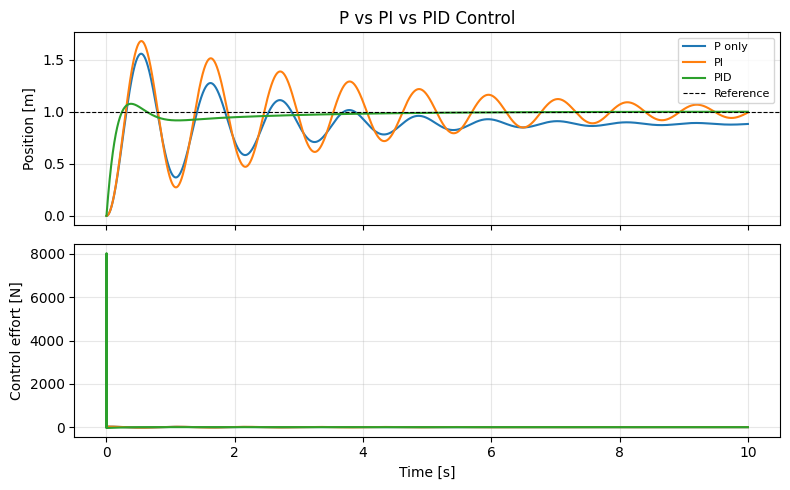

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

for label, x in results.items():
    axes[0].plot(t, x, label=label)
axes[0].axhline(ref, color="k", linestyle="--", linewidth=0.8, label="Reference")
axes[0].set_ylabel("Position [m]")
axes[0].set_title("P vs PI vs PID Control")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for label, u in efforts.items():
    axes[1].plot(t, u, label=label)
axes[1].set_ylabel("Control effort [N]")
axes[1].set_xlabel("Time [s]")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Student Exercise

1. Set `Ki = 50.0` in the PI case. What happens? (Hint: look for oscillation.)
2. Remove the D term from PID (`Kd = 0`). How does overshoot change?
3. Add a fourth controller: `"PD": {"Kp": 30.0, "Ki": 0.0, "Kd": 8.0}` and compare.